In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from scipy import stats

nltk.download('vader_lexicon', quiet=True)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.family'] = 'serif'
print("Environment Ready!")

Environment Ready!


In [7]:
import pandas as pd

# Load your datasets
df_news = pd.read_csv('Data/raw_analyst_ratings.csv')
df_stock = pd.read_csv('Data/AAPL.csv')

# FIX: Force format to 'ISO8601' which perfectly maps strings like "2020-05-22 00:00:00".
# Setting utc=True bypasses the mixed timezone caching bug.
df_news['normalized_date'] = pd.to_datetime(
    df_news['date'], 
    format='ISO8601', 
    utc=True
).dt.tz_localize(None).dt.normalize()

# Convert Stock 'Date' to datetime
df_stock['Date'] = pd.to_datetime(df_stock['Date'])

In [9]:
# 1. Extract unique news dates and sort them
unique_news_dates = pd.DataFrame({'news_date': df_news['normalized_date'].unique()}).sort_values('news_date')

# 2. Extract unique valid trading days from your stock data and sort them
trading_days = pd.DataFrame({'trading_date': df_stock['Date'].unique()}).sort_values('trading_date')

# 3. FIX: Changed direction to 'forward'
# This means if a news_date lands on a weekend/holiday, it rolls FORWARD to the next trading day.
date_mapping = pd.merge_asof(
    unique_news_dates, 
    trading_days, 
    left_on='news_date', 
    right_on='trading_date', 
    direction='forward'
)

# 4. Map these aligned trading dates back into your main news dataset
df_news = df_news.merge(date_mapping, left_on='normalized_date', right_on='news_date', how='left')
df_news = df_news.drop(columns=['news_date'])

# 5. Filter for your target stock (e.g., AAPL) and merge for the final correlation dataset
df_news_aapl = df_news[df_news['stock'] == 'AAPL']
final_aligned_dataset = pd.merge(
    df_news_aapl, 
    df_stock, 
    left_on='trading_date', 
    right_on='Date', 
    how='inner'
)

In [10]:
# import pandas as pd
# import glob
# import os

# # ==========================================
# # 1. LOAD AND CLEAN NEWS DATA
# # ==========================================
# df_news = pd.read_csv('Data/raw_analyst_ratings.csv')

# # Handle the mixed date formats and strip timezones/times
# df_news['normalized_date'] = pd.to_datetime(
#     df_news['date'], 
#     format='ISO8601', 
#     utc=True
# ).dt.tz_localize(None).dt.normalize()

# # Ensure stock symbols in news are clean strings (uppercase, no whitespace)
# df_news['stock'] = df_news['stock'].astype(str).str.strip().str.upper()


# # ==========================================
# # 2. CREATE A MASTER TRADING CALENDAR
# # ==========================================
# # Find all stock CSV files inside your Data folder
# stock_files = glob.glob('Data/*.csv') 
# # Filter out the news file if it's in the same folder
# stock_files = [f for f in stock_files if 'raw_analyst_ratings' not in f]

# all_trading_days = set()

# # Loop through all stock files to gather every valid market trading day
# for file in stock_files:
#     df_temp = pd.read_csv(file)
#     # Standardize the Date column name to handle case sensitivity (e.g., 'date' vs 'Date')
#     df_temp.columns = [c.capitalize() for c in df_temp.columns]
    
#     if 'Date' in df_temp.columns:
#         dates = pd.to_datetime(df_temp['Date']).dt.normalize().dropna()
#         all_trading_days.update(dates)

# # Turn the master list of unique dates into a sorted DataFrame
# master_calendar = pd.DataFrame({'trading_date': sorted(list(all_trading_days))})


# # ==========================================
# # 3. RUN THE ROLL-FORWARD DATE ALIGNMENT
# # ==========================================
# unique_news_dates = pd.DataFrame({'news_date': df_news['normalized_date'].unique()}).sort_values('news_date')

# # Use direction='forward' to map weekends/holidays to the NEXT available trading day
# date_mapping = pd.merge_asof(
#     unique_news_dates, 
#     master_calendar, 
#     left_on='news_date', 
#     right_on='trading_date', 
#     direction='forward'
# )

# # Map the aligned trading dates back into the master news dataframe
# df_news = df_news.merge(date_mapping, left_on='normalized_date', right_on='news_date', how='left')
# df_news = df_news.drop(columns=['news_date'])


# # ==========================================
# # 4. LOOP AND MERGE EACH INDIVIDUAL STOCK
# # ==========================================
# # This dictionary will hold your final aligned datasets for each company
# all_aligned_datasets = {}

# for file in stock_files:
#     # Extract the ticker name from the file name (e.g., 'Data/AAPL.csv' -> 'AAPL')
#     ticker = os.path.splitext(os.path.basename(file))[0].upper()
    
#     # Read the individual company stock data
#     df_stock = pd.read_csv(file)
#     df_stock.columns = [c.capitalize() for c in df_stock.columns] # Normalize column names
#     df_stock['Date'] = pd.to_datetime(df_stock['Date']).dt.normalize()
    
#     # Filter news specifically for this ticker
#     df_news_ticker = df_news[df_news['stock'] == ticker]
    
#     # Merge news with stock data on the aligned trading date
#     df_final = pd.merge(
#         df_news_ticker, 
#         df_stock, 
#         left_on='trading_date', 
#         right_on='Date', 
#         how='inner'
#     )
    
#     # Store the result in our dictionary
#     all_aligned_datasets[ticker] = df_final
#     print(f"Successfully aligned {ticker}: {len(df_final)} rows matched.")

# # ==========================================
# # 5. HOW TO ACCESS YOUR DATA
# # ==========================================
# # You can now access any dataset directly via its ticker symbol:
# # e.g., df_aapl = all_aligned_datasets['AAPL']
# #       df_goog = all_aligned_datasets['GOOG']

Successfully aligned AMZN: 278 rows matched.
Successfully aligned NVDA: 3146 rows matched.
Successfully aligned META: 0 rows matched.
Successfully aligned GOOG: 1199 rows matched.
Successfully aligned AAPL: 441 rows matched.


In [11]:
import pandas as pd
import glob
import os

# ==========================================
# 1. LOAD AND CLEAN NEWS DATA
# ==========================================
print("Loading and cleaning news data...")
df_news = pd.read_csv('Data/raw_analyst_ratings.csv')

# Handle the mixed date formats and strip timezones/times cleanly
df_news['normalized_date'] = pd.to_datetime(
    df_news['date'], 
    format='ISO8601', 
    utc=True
).dt.tz_localize(None).dt.normalize()

# Ensure stock symbols in news are clean strings (uppercase, no whitespace)
df_news['stock'] = df_news['stock'].astype(str).str.strip().str.upper()


# ==========================================
# 2. CREATE A MASTER TRADING CALENDAR
# ==========================================
print("Generating master trading calendar...")

# Step A: Find all CSV files inside your Data folder
all_files = glob.glob('Data/*.csv') 

# Step B: THE SAFETY CODE 
# This explicitly excludes the news file so the loop never touches it.
stock_files = [f for f in all_files if 'raw_analyst_ratings' not in f]

# Print out the files we found to verify the safety code worked
print(f"Found stock files to process: {[os.path.basename(f) for f in stock_files]}")

all_trading_days = set()

# Loop through only the safe stock files to gather every valid market trading day
for file in stock_files:
    df_temp = pd.read_csv(file)
    # Standardize column names to handle case sensitivity (e.g., 'date' vs 'Date')
    df_temp.columns = [c.capitalize() for c in df_temp.columns]
    
    if 'Date' in df_temp.columns:
        dates = pd.to_datetime(df_temp['Date']).dt.normalize().dropna()
        all_trading_days.update(dates)

# Turn the master list of unique dates into a sorted DataFrame
master_calendar = pd.DataFrame({'trading_date': sorted(list(all_trading_days))})


# ==========================================
# 3. RUN THE ROLL-FORWARD DATE ALIGNMENT
# ==========================================
print("Aligning news dates (rolling forward weekends/holidays)...")
unique_news_dates = pd.DataFrame({'news_date': df_news['normalized_date'].unique()}).sort_values('news_date')

# Use direction='forward' to map weekends/holidays to the NEXT available trading day
date_mapping = pd.merge_asof(
    unique_news_dates, 
    master_calendar, 
    left_on='news_date', 
    right_on='trading_date', 
    direction='forward'
)

# Map the aligned trading dates back into the master news dataframe
df_news = df_news.merge(date_mapping, left_on='normalized_date', right_on='news_date', how='left')
df_news = df_news.drop(columns=['news_date'])


# ==========================================
# 4. LOOP AND MERGE EACH INDIVIDUAL STOCK
# ==========================================
# This dictionary will hold your final aligned datasets for each company
all_aligned_datasets = {}

print("Merging news with individual stock datasets...")
for file in stock_files:
    # Extract the ticker name from the file name (e.g., 'Data/AAPL.csv' -> 'AAPL')
    ticker = os.path.splitext(os.path.basename(file))[0].upper()
    
    # Read the individual company stock data
    df_stock = pd.read_csv(file)
    df_stock.columns = [c.capitalize() for c in df_stock.columns] # Normalize column names
    df_stock['Date'] = pd.to_datetime(df_stock['Date']).dt.normalize()
    
    # Filter news specifically for this ticker
    df_news_ticker = df_news[df_news['stock'] == ticker]
    
    # Merge news with stock data on the aligned trading date
    df_final = pd.merge(
        df_news_ticker, 
        df_stock, 
        left_on='trading_date', 
        right_on='Date', 
        how='inner'
    )
    
    # Store the result in our dictionary
    all_aligned_datasets[ticker] = df_final
    print(f"  -> Successfully aligned {ticker}: {len(df_final)} rows matched.")

print("\nAll datasets successfully processed and aligned!")

Loading and cleaning news data...
Generating master trading calendar...
Found stock files to process: ['AMZN.csv', 'NVDA.csv', 'META.csv', 'GOOG.csv', 'AAPL.csv']
Aligning news dates (rolling forward weekends/holidays)...
Merging news with individual stock datasets...
  -> Successfully aligned AMZN: 278 rows matched.
  -> Successfully aligned NVDA: 3146 rows matched.
  -> Successfully aligned META: 0 rows matched.
  -> Successfully aligned GOOG: 1199 rows matched.
  -> Successfully aligned AAPL: 441 rows matched.

All datasets successfully processed and aligned!


In [13]:
pip install nltk


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the VADER lexicon (only needs to be run once)
nltk.download('vader_lexicon')

# Initialize the VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

print("Starting sentiment analysis across all datasets...")

# Loop through each aligned company dataset in your dictionary
for ticker, df in all_aligned_datasets.items():
    if df.empty:
        print(f"Skipping {ticker} because the dataset is empty.")
        continue
        
    print(f"Processing sentiment scores for {ticker}...")
    
    # 1. Apply VADER to the headline column to get a dictionary of scores
    # We use a lambda function to grab the 'compound' score specifically
    df['sentiment_score'] = df['headline'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
    
    # Optional: If you also want raw positive, negative, and neutral breakdowns:
    # df['sentiment_pos'] = df['headline'].apply(lambda x: sia.polarity_scores(str(x))['pos'])
    # df['sentiment_neg'] = df['headline'].apply(lambda x: sia.polarity_scores(str(x))['neg'])
    # df['sentiment_neu'] = df['headline'].apply(lambda x: sia.polarity_scores(str(x))['neu'])
    
    # Update the master dictionary with the new sentiment-loaded DataFrame
    all_aligned_datasets[ticker] = df
    
    print(f"  -> {ticker} now contains 'sentiment_score'. Sample range: {df['sentiment_score'].min()} to {df['sentiment_score'].max()}")

print("\nSentiment analysis complete! All datasets are ready for correlation analysis.")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/tekabe/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Starting sentiment analysis across all datasets...
Processing sentiment scores for AMZN...
  -> AMZN now contains 'sentiment_score'. Sample range: -0.8689 to 0.8807
Processing sentiment scores for NVDA...
  -> NVDA now contains 'sentiment_score'. Sample range: -0.886 to 0.9552
Skipping META because the dataset is empty.
Processing sentiment scores for GOOG...
  -> GOOG now contains 'sentiment_score'. Sample range: -0.9393 to 0.9477
Processing sentiment scores for AAPL...
  -> AAPL now contains 'sentiment_score'. Sample range: -0.9062 to 0.936

Sentiment analysis complete! All datasets are ready for correlation analysis.


In [16]:
print("Calculating daily stock returns...")

for ticker in list(all_aligned_datasets.keys()):
    df = all_aligned_datasets[ticker]
    
    if df.empty:
        continue
        
    # 1. Sort the dataset chronologically by date to ensure shifts are accurate
    df = df.sort_values('trading_date').reset_index(drop=True)
    
    # 2. SAFETY CHECK: Identify whether to use 'Close' or 'Close' with specific capitalization
    # We look for 'Close' or 'close' dynamically
    close_col = [col for col in df.columns if col.lower() == 'close']
    
    if not close_col:
        print(f"  ⚠️ Warning: Could not find any Close column for {ticker}! Columns found: {list(df.columns)}")
        continue
    
    target_close = close_col[0] # Grab the actual name found (e.g., 'Close')
    
    # 3. Calculate daily return percentage using the standard Close price
    df['daily_return'] = df[target_close].pct_change() * 100
    
    # 4. Handle the very first row's NaN value safely
    df['daily_return'] = df['daily_return'].fillna(0)
    
    # Update our master dataset dictionary
    all_aligned_datasets[ticker] = df
    
    print(f"  -> {ticker}: Calculated daily returns using '{target_close}'. Sample range: {df['daily_return'].min():.2f}% to {df['daily_return'].max():.2f}%")

print("\nDaily stock returns successfully calculated using available Close prices!")

Calculating daily stock returns...
  -> AMZN: Calculated daily returns using 'Close'. Sample range: -7.60% to 5.20%
  -> NVDA: Calculated daily returns using 'Close'. Sample range: -22.51% to 29.81%
  -> GOOG: Calculated daily returns using 'Close'. Sample range: -11.10% to 10.45%
  -> AAPL: Calculated daily returns using 'Close'. Sample range: -12.86% to 11.98%

Daily stock returns successfully calculated using available Close prices!


Starting Aggregation and Correlation Analysis...

Analyzing AMZN...
  -> Pearson Correlation Coefficient: 0.1576 (p-value: 4.2324e-01)


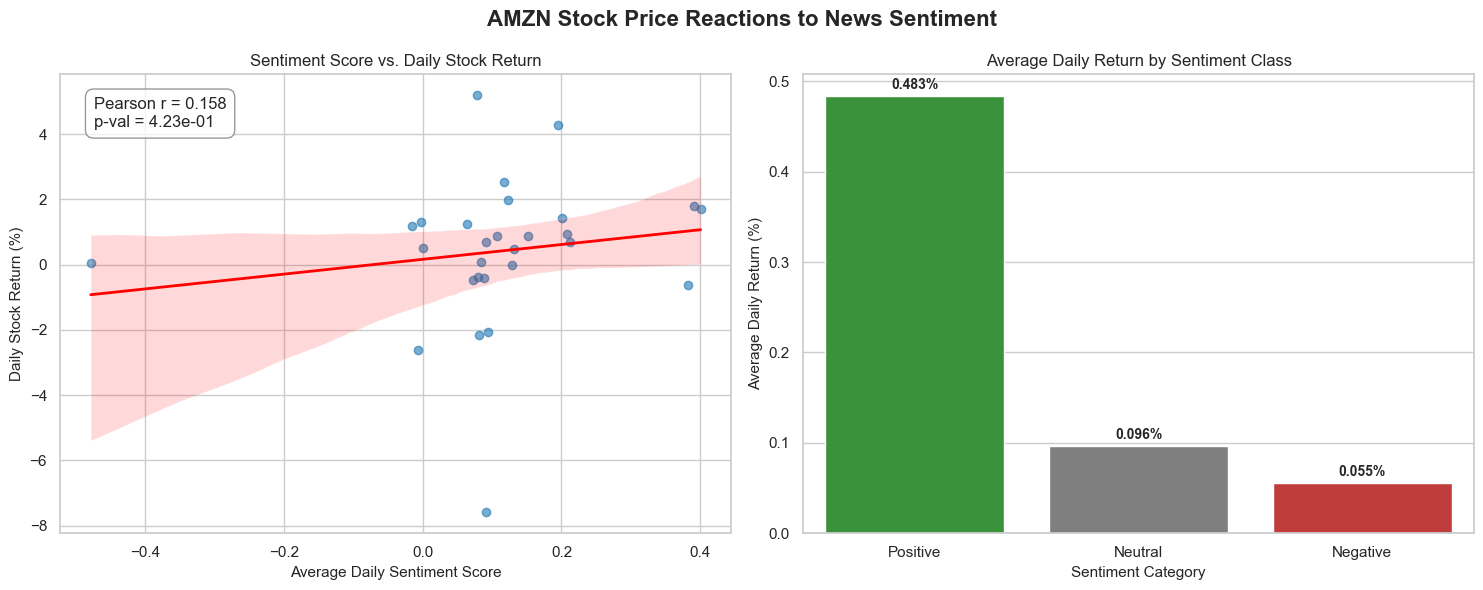

Analyzing NVDA...
  -> Pearson Correlation Coefficient: 0.1718 (p-value: 5.0461e-09)


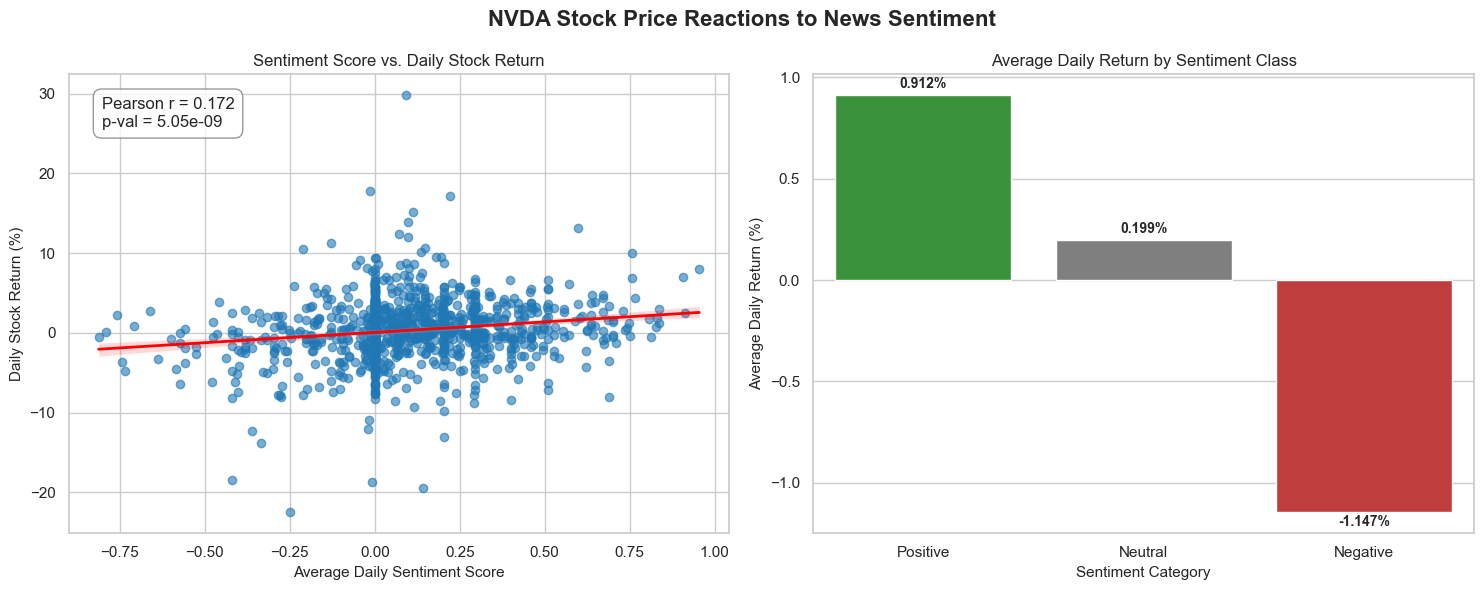

Analyzing GOOG...
  -> Pearson Correlation Coefficient: 0.1699 (p-value: 1.3558e-03)


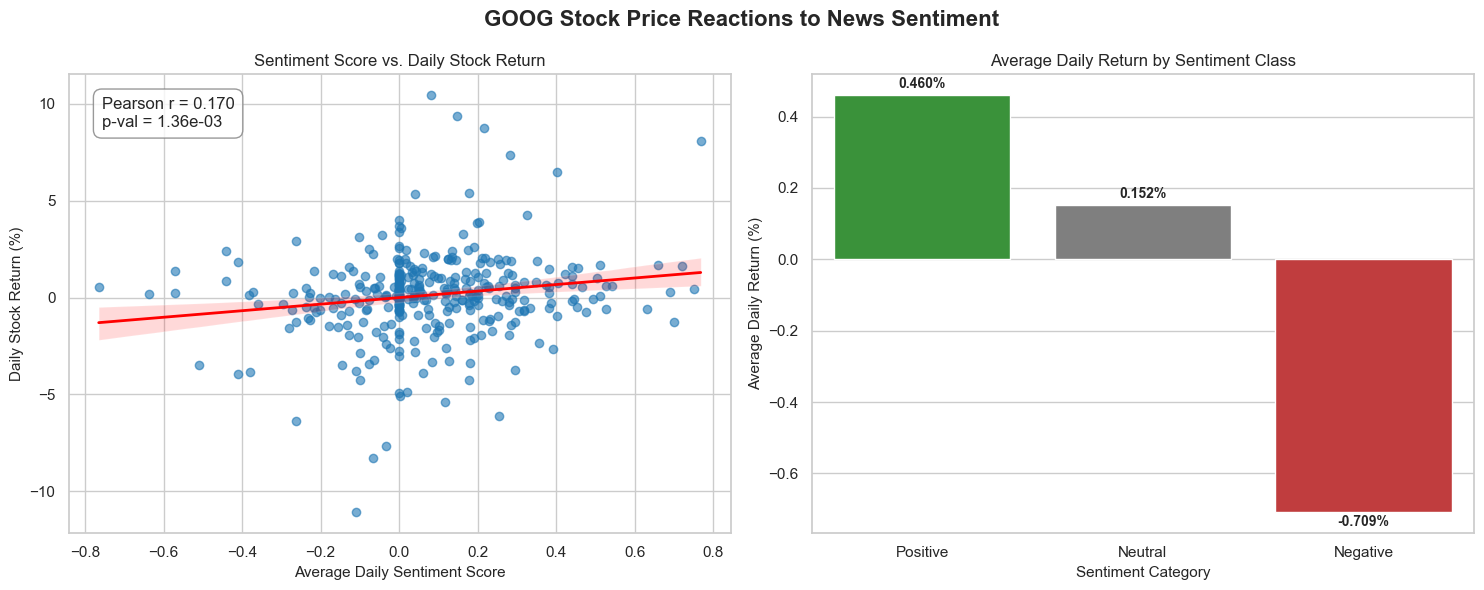

Analyzing AAPL...
  -> Pearson Correlation Coefficient: 0.0764 (p-value: 5.5831e-01)


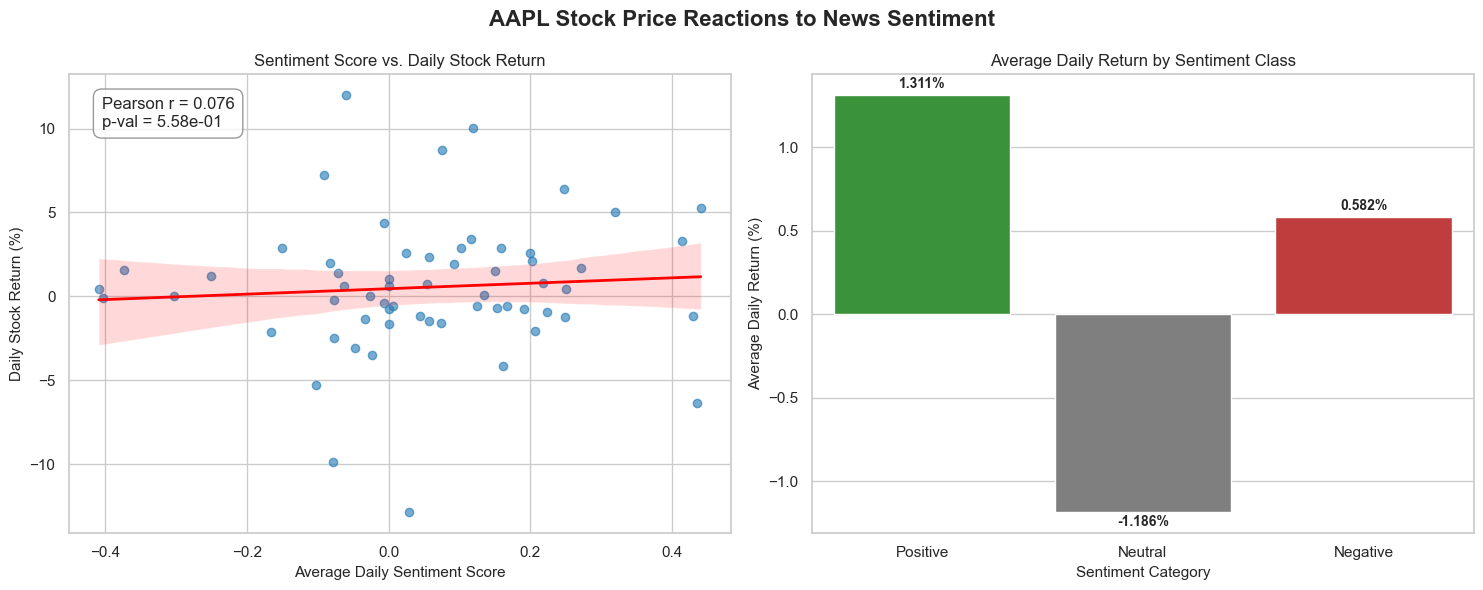


All correlation analyses and visualizations are complete!


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Set style for clean, professional plots
sns.set_theme(style="whitegrid")

print("Starting Aggregation and Correlation Analysis...\n")

for ticker in list(all_aligned_datasets.keys()):
    df_merged = all_aligned_datasets[ticker]
    
    if df_merged.empty:
        continue
        
    print(f"Analyzing {ticker}...")
    
    # =========================================================================
    # 1. AGGREGATE MULTIPLE ARTICLES PER DAY
    # =========================================================================
    # Group by trading_date and calculate the mean of the sentiment scores.
    # We also keep 'daily_return' and 'Volume'. Since stock data is identical 
    # for a given day, taking the 'first' or 'mean' value yields the correct daily number.
    df_daily = df_merged.groupby('trading_date').agg({
        'sentiment_score': 'mean',
        'daily_return': 'first',
        'Volume': 'first'
    }).reset_index()
    
    # Rename the aggregated column for absolute clarity
    df_daily = df_daily.rename(columns={'sentiment_score': 'avg_daily_sentiment'})
    
    # Ensure we have enough data points to compute a meaningful correlation
    if len(df_daily) < 3:
        print(f"  ⚠️ Skipping visualizations for {ticker}: Not enough data points ({len(df_daily)} days).")
        continue

    # =========================================================================
    # 2. CALCULATE PEARSON CORRELATION COEFFICIENT
    # =========================================================================
    corr_coef, p_value = pearsonr(df_daily['avg_daily_sentiment'], df_daily['daily_return'])
    print(f"  -> Pearson Correlation Coefficient: {corr_coef:.4f} (p-value: {p_value:.4e})")

    # =========================================================================
    # 3. CLASSIFY DAYS BY SENTIMENT CATEGORY
    # =========================================================================
    # Define custom boundaries: 
    # Compound score > 0.05 is Positive, < -0.05 is Negative, everything else is Neutral
    conditions = [
        (df_daily['avg_daily_sentiment'] > 0.05),
        (df_daily['avg_daily_sentiment'] < -0.05)
    ]
    choices = ['Positive', 'Negative']
    df_daily['sentiment_category'] = np.select(conditions, choices, default='Neutral')

    # Calculate average daily return per sentiment category
    category_returns = df_daily.groupby('sentiment_category')['daily_return'].mean().reindex(['Positive', 'Neutral', 'Negative'])

    # =========================================================================
    # 4. VISUALIZATION: SIDE-BY-SIDE PLOTS
    # =========================================================================
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'{ticker} Stock Price Reactions to News Sentiment', fontsize=16, fontweight='bold')

    # Plot A: Scatter Plot with Regression Line
    sns.regplot(
        ax=axes[0],
        data=df_daily,
        x='avg_daily_sentiment',
        y='daily_return',
        scatter_kws={'alpha':0.6, 'color': '#1f77b4'},
        line_kws={'color': 'red', 'linewidth': 2}
    )
    axes[0].set_title('Sentiment Score vs. Daily Stock Return', fontsize=12)
    axes[0].set_xlabel('Average Daily Sentiment Score', fontsize=11)
    axes[0].set_ylabel('Daily Stock Return (%)', fontsize=11)
    
    # Annotate the plot with the Pearson Correlation value
    axes[0].text(
        0.05, 0.95, 
        f'Pearson r = {corr_coef:.3f}\np-val = {p_value:.2e}', 
        transform=axes[0].transAxes, 
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
    )

    # Plot B: Categorical Bar Chart
    colors = ['#2ca02c', '#7f7f7f', '#d62728'] # Green for Pos, Gray for Neu, Red for Neg
    sns.barplot(
        ax=axes[1],
        x=category_returns.index,
        y=category_returns.values,
        palette=colors,
        hue=category_returns.index,
        legend=False
    )
    axes[1].set_title('Average Daily Return by Sentiment Class', fontsize=12)
    axes[1].set_xlabel('Sentiment Category', fontsize=11)
    axes[1].set_ylabel('Average Daily Return (%)', fontsize=11)
    
    # Add value labels on top of the bars
    for bar in axes[1].patches:
        height = bar.get_height()
        axes[1].annotate(
            f'{height:.3f}%',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3) if height >= 0 else (0, -12),  # Adjust text position based on sign
            textcoords="offset points",
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

print("\nAll correlation analyses and visualizations are complete!")
#